## Interactive notebook to test GA optimisation of excitation transfer

## 1. Imports

In [1]:
from qtransfer.network.adjacency import random_adjacency
from qtransfer.network import Network, ControlSequence

from qgene.optimisation import  GeneticOptimiser
from qgene.operators import UniformCrossover, DiscreteMutation
from qgene.selection import UniformSelection
from qgene.individual import Individual

from qsim.state import DensityMatrix
import numpy as np
import random

/Users/matthewmackinnon/Documents/repos/ExcitationTransfer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Target

Setting network size and connections

In [ ]:
n=6
p=0.7
target_adj = random_adjacency(n, p, seed = 112)

Configuring initial state

In [ ]:

initial_node = 0
rho0 = np.zeros((n,n))

## Choose this for localised excitation
rho0[initial_node, initial_node] = 1

## Choose this for distributed excitation
#rho0 = np.outer(np.array([1/(n**0.5) for i in range(n)]), np.array([1/(n**0.5) for i in range(n)]))

rho0 = DensityMatrix(rho0)


Setting up sink and environmental couplings

In [21]:
sink_locations = [5]
sink_coupling_strengths = [1]

## Change this to alter the rate of dissipation
env_damping = [0.3 for i in range(n)]

Visualising the network structure - the last two nodes represent the sink and the environment

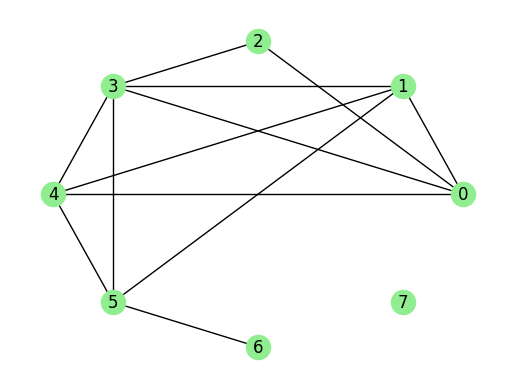

In [23]:
target_network = Network(target_adj, rho0=rho0, sink_coupling_strengths=sink_coupling_strengths, sink_locations=sink_locations, local_loss_strengths=env_damping)
d = target_network.diagram()

Network energy transfer of: 0.6233992773914052


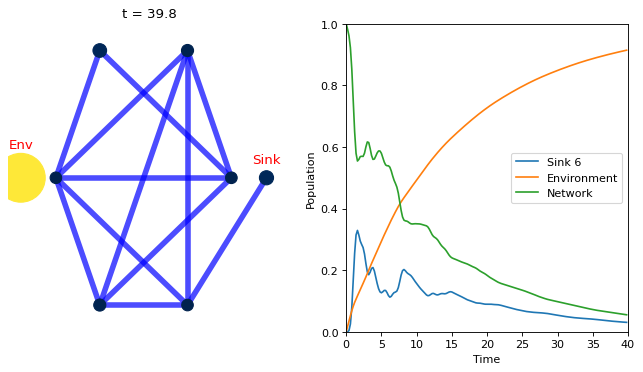

In [26]:
ts = 0.2
n_steps = 200
print(f'Network energy transfer of: {target_network.energy_transfer}')
target_network.animateEvolutionWithConnections(ts, n_steps)

## 3. Settings

Setting up dynamic control settings

In [27]:
# Define the times at which the Hamiltonian can be modified
control_times = [0, 3]

In [29]:
# Selecting the adjacency matrix elements to provide control over, this setup is the full off-diagonal adjacency matrix
control_mask = np.zeros((n,n))
control_mask[np.tril_indices(n, k=-1)] = 1
control_mask = (control_mask == 1)

In [30]:
vectorised_adj = target_adj[control_mask].flatten()

Configuring the discrete values that the control matrix elements can take, modify the spacing to np.linspace(0, 1, x) to allow for x discrete values

In [31]:
limits = [] 

for t in control_times:
    limits += [np.linspace(0, 1, 20) - x for x in vectorised_adj]

## 4. Initial Population

In [32]:
pop_size = 200

In [33]:
pop = [Individual(tuple(random.choice(lims) for lims in limits)) for i in range(pop_size)]


# 5. Optimiser

Configuring optimisation functions. Optimisation is always a maximisation procedure, uncomment net.control_cost to include the energetic cost of control operations

In [34]:
def score_func(pop: list[Individual]):
    for p in pop:
        if p.score is None:
            control = ControlSequence.from_individual(control_times, p, n, control_mask)
            net = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)
            p.score = net.energy_transfer# - net.control_cost

Genetic operator setup, modify p in DiscreteMutation to control mutation rate, pop_fraction to control how much of the population is used to generate new solutions

In [35]:
crossover = UniformCrossover()
mutation = DiscreteMutation(p = 0.1, vals=limits)
selection = UniformSelection(pop_fraction=0.25)

Run genetic optimiser, modify the retention parameter to increase or decrease the fraction of the old population that is retained each generation

In [36]:
g = GeneticOptimiser(pop, score_func=score_func, selection_func=selection, crossover_func=crossover, mutation_func=mutation, retention=0.02, verbose=1)

In [37]:
g.optimise(early_stopping=True)

Best: 0.7801 | Mean: 0.6535 | Div: 0.2389:  16%|█▌        | 16/100 [05:33<29:10, 20.84s/it]


KeyboardInterrupt: 

Visualising optimal genetic algorithm solution

In [38]:
control = ControlSequence.from_individual(control_times, g.optimal_individual, n, control_mask)
net = Network(A = target_adj, rho0=rho0, control = control, sink_locations=sink_locations, sink_coupling_strengths=sink_coupling_strengths, local_loss_strengths=env_damping)

Network energy transfer of: 0.7800620857484828
Increase in energy transfer of: 0.15666280835707758


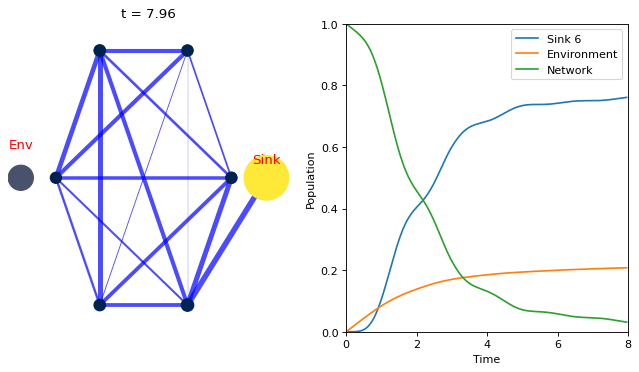

In [42]:
print(f'Network energy transfer of: {net.energy_transfer}')
print(f'Increase in energy transfer of: {net.energy_transfer - target_network.energy_transfer}')
net.animateEvolutionWithConnections(ts*0.2, n_steps)